In [1]:
# ============================================================
# 100936_00001 — CT METADATA/RESAMPLING INVESTIGATION
# DO NOT MODIFY THE ORIGINAL CT
# ============================================================

from pathlib import Path
import SimpleITK as sitk
import numpy as np

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

OUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_CT = (
    OUT_DIR
    / f"{study_id}_ct_resampled_0p5mm.nii.gz"
)


print("=" * 70)
print("100936_00001 — CT RESAMPLING EXPERIMENT")
print("=" * 70)

print("\nOriginal CT:")
print(CT_PATH)

print("\nManual label:")
print(LABEL_PATH)

print("\nOutput candidate CT:")
print(OUTPUT_CT)


# ------------------------------------------------------------
# Load original CT
# ------------------------------------------------------------

ct = sitk.ReadImage(str(CT_PATH))
label = sitk.ReadImage(str(LABEL_PATH))

print("\n" + "-" * 70)
print("ORIGINAL GEOMETRY")
print("-" * 70)

print("CT size      :", ct.GetSize())
print("CT spacing   :", ct.GetSpacing())
print("CT origin    :", ct.GetOrigin())
print("CT direction :", ct.GetDirection())

print("\nLabel size      :", label.GetSize())
print("Label spacing   :", label.GetSpacing())
print("Label origin    :", label.GetOrigin())
print("Label direction :", label.GetDirection())


# ------------------------------------------------------------
# Create candidate CT with 0.5 mm Z spacing
#
# Preserve the original physical extent.
# X/Y spacing stay unchanged.
# ------------------------------------------------------------

original_size = np.array(
    ct.GetSize(),
    dtype=int
)

original_spacing = np.array(
    ct.GetSpacing(),
    dtype=float
)

target_spacing = np.array(
    [
        original_spacing[0],
        original_spacing[1],
        0.5,
    ],
    dtype=float
)

physical_extent = (
    (original_size - 1)
    * original_spacing
)

new_size = np.round(
    physical_extent / target_spacing
).astype(int) + 1

new_size = tuple(
    int(x) for x in new_size
)

target_spacing_tuple = tuple(
    float(x) for x in target_spacing
)


print("\n" + "-" * 70)
print("CANDIDATE RESAMPLING")
print("-" * 70)

print("Original size      :", ct.GetSize())
print("Original spacing   :", ct.GetSpacing())

print("Target spacing     :", target_spacing_tuple)
print("Calculated size    :", new_size)

print(
    "Original Z extent  :",
    physical_extent[2],
    "mm"
)


# ------------------------------------------------------------
# Resample CT only
# ------------------------------------------------------------

resampler = sitk.ResampleImageFilter()

resampler.SetOutputSpacing(
    target_spacing_tuple
)

resampler.SetSize(
    new_size
)

resampler.SetOutputOrigin(
    ct.GetOrigin()
)

resampler.SetOutputDirection(
    ct.GetDirection()
)

resampler.SetTransform(
    sitk.Transform(3, sitk.sitkIdentity)
)

resampler.SetInterpolator(
    sitk.sitkLinear
)

resampler.SetDefaultPixelValue(
    -1024
)

resampled_ct = resampler.Execute(ct)


# ------------------------------------------------------------
# Save candidate
# ------------------------------------------------------------

sitk.WriteImage(
    resampled_ct,
    str(OUTPUT_CT)
)

print("\n✓ Candidate CT saved:")
print(OUTPUT_CT)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

check = sitk.ReadImage(
    str(OUTPUT_CT)
)

print("\n" + "-" * 70)
print("CANDIDATE CT GEOMETRY")
print("-" * 70)

print("Size      :", check.GetSize())
print("Spacing   :", check.GetSpacing())
print("Origin    :", check.GetOrigin())
print("Direction :", check.GetDirection())

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)
print(
    "\nOriginal CT was NOT modified."
)

100936_00001 — CT RESAMPLING EXPERIMENT

Original CT:
d:\Pancreatic_Cancer_Thesis\data\raw_ct\100936_00001_0000.nii.gz

Manual label:
d:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels\100936_00001.nii.gz

Output candidate CT:
d:\Pancreatic_Cancer_Thesis\data\processed\anomaly_investigation\100936_00001_ct_resampled_0p5mm.nii.gz

----------------------------------------------------------------------
ORIGINAL GEOMETRY
----------------------------------------------------------------------
CT size      : (1024, 1024, 406)
CT spacing   : (0.3910059928894043, 0.3910059928894043, 0.7543209791183472)
CT origin    : (-186.32794189453125, -199.99981689453125, 1500.5)
CT direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Label size      : (1024, 1024, 406)
Label spacing   : (0.3910059928894043, 0.3910059928894043, 0.5)
Label origin    : (-186.32794189453125, -199.99981689453125, 1500.5)
Label direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

----------------------------------

RESAMPLED CT HEADER
Size      : (1024, 1024, 612)
Spacing   : (0.3910059928894043, 0.3910059928894043, 0.5)
Origin    : (-186.32794189453125, -199.99981689453125, 1500.5)
Direction : (1.0, -0.0, -0.0, -0.0, 1.0, -0.0, 0.0, 0.0, 1.0)


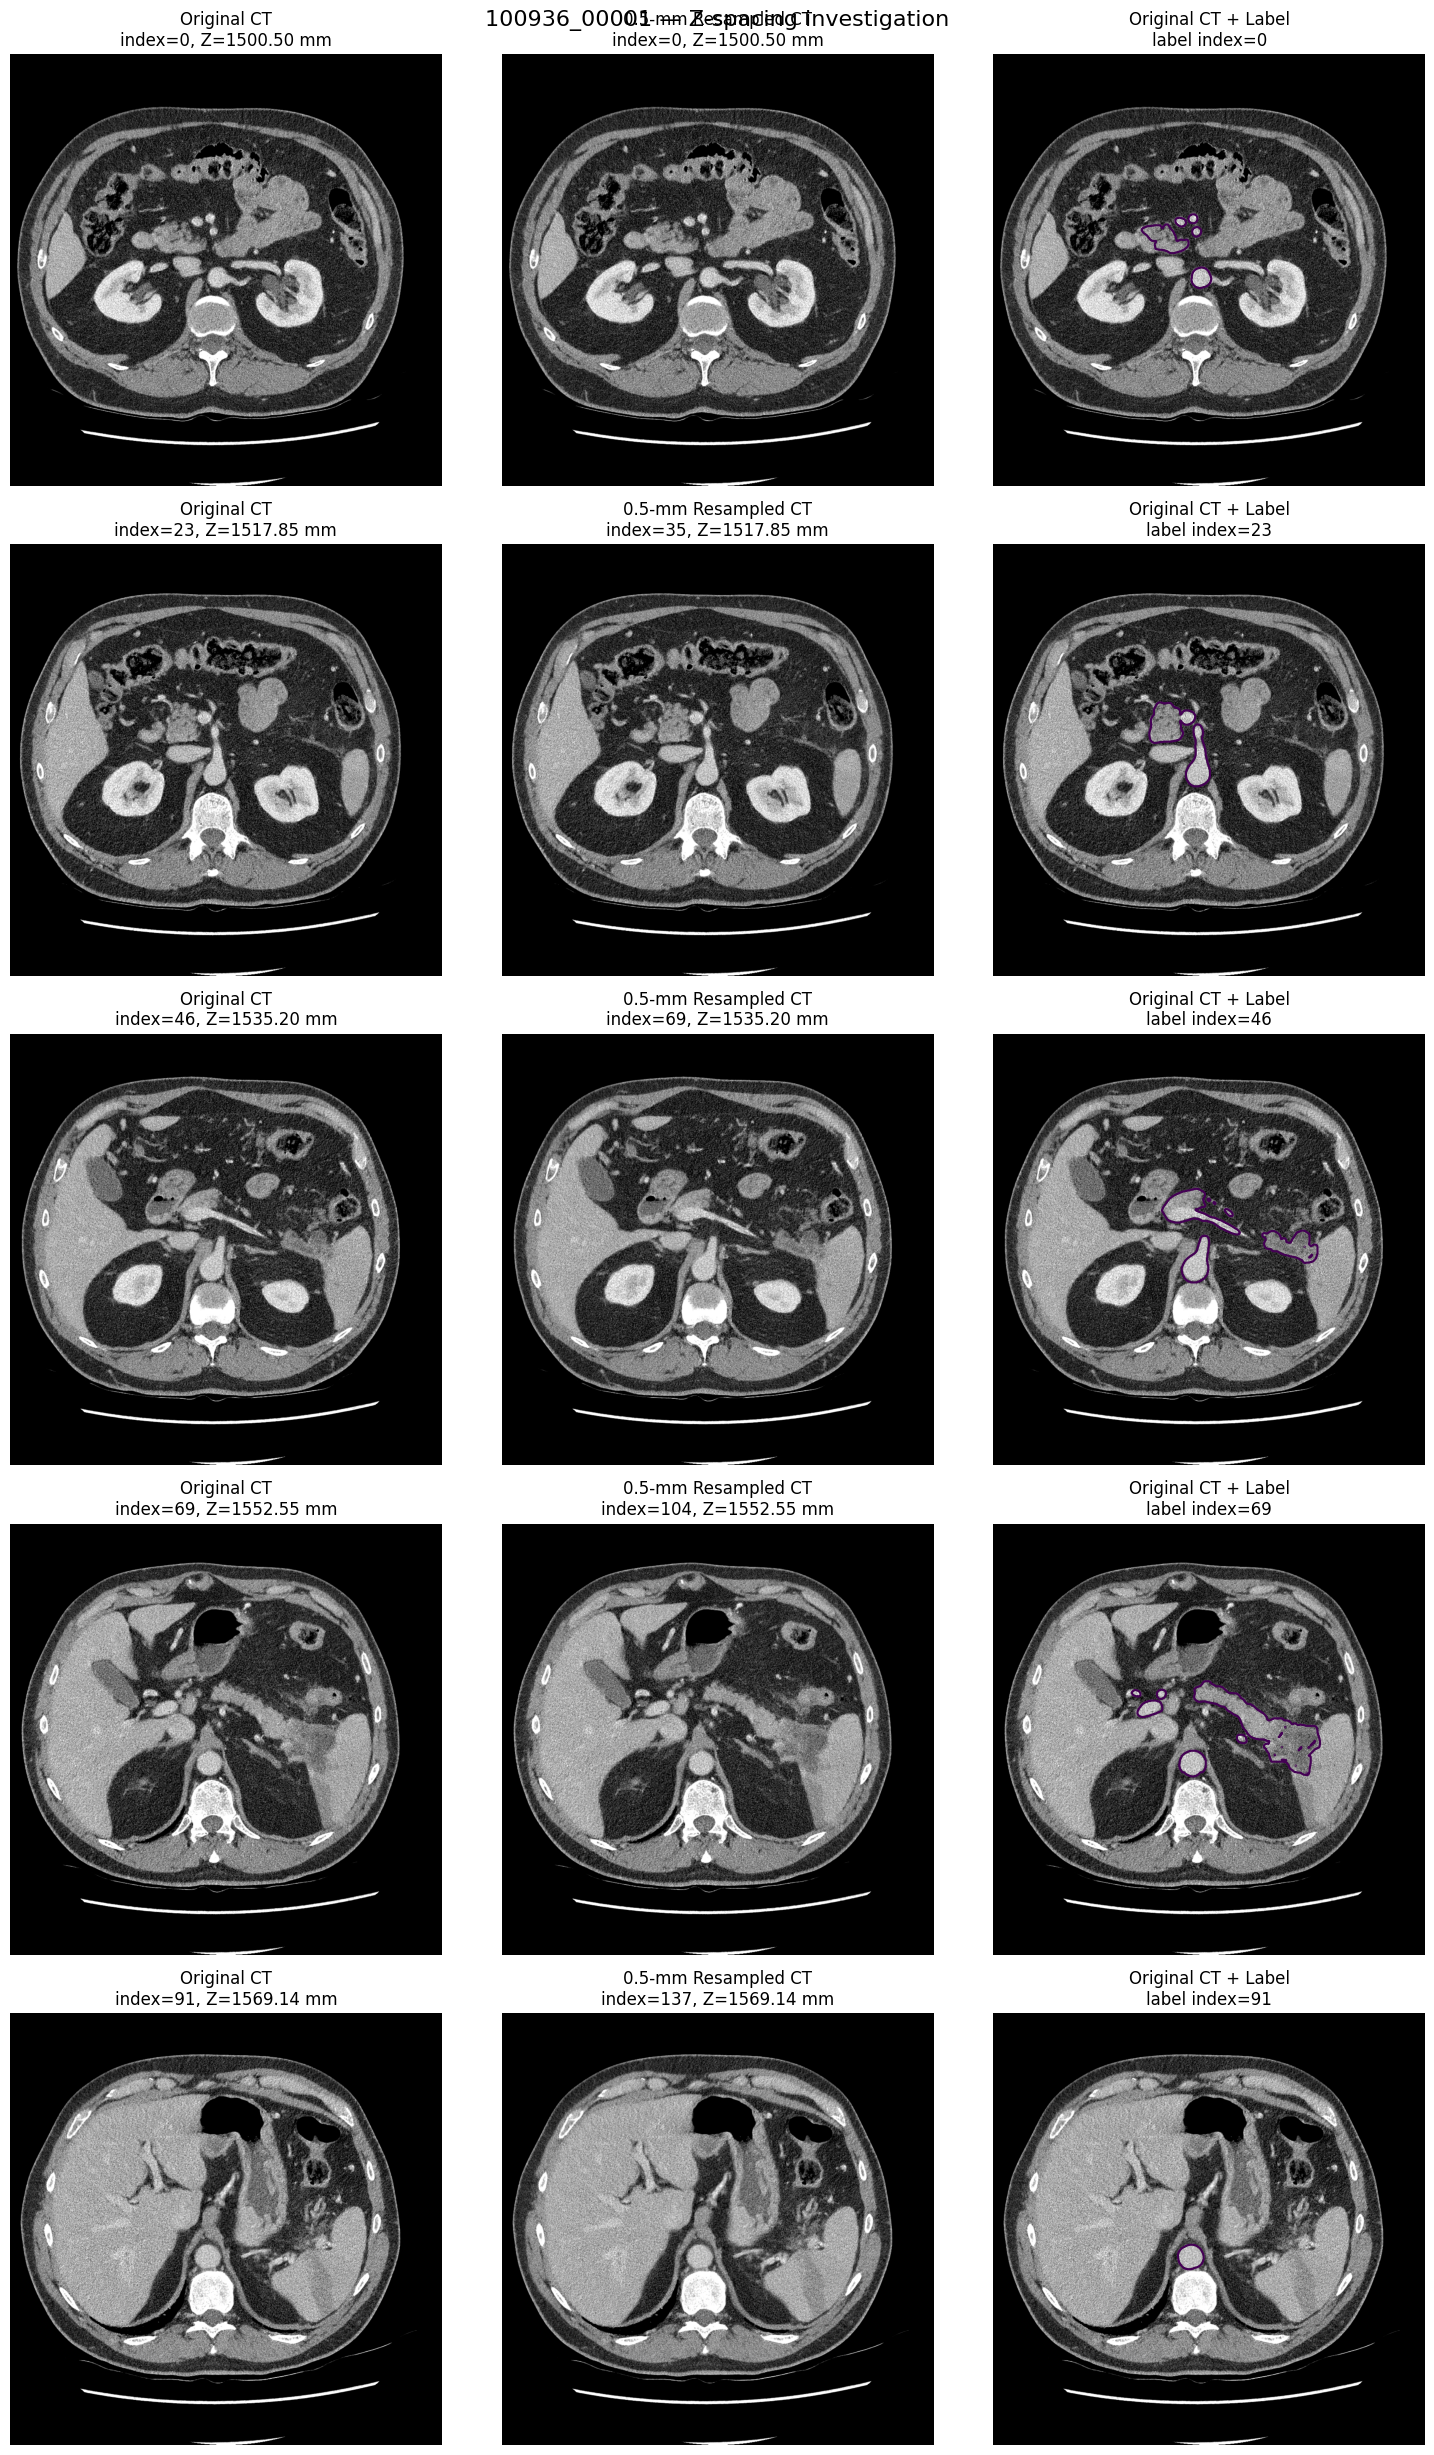

In [2]:
# ============================================================
# 100936_00001 — MEMORY-SAFE CT/0.5-mm ALIGNMENT INSPECTION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
from pathlib import Path


study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ORIGINAL_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

RESAMPLED_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
    / f"{study_id}_ct_resampled_0p5mm.nii.gz"
)


# ------------------------------------------------------------
# Read original CT and label normally
# ------------------------------------------------------------

original_ct = sitk.ReadImage(
    str(ORIGINAL_CT_PATH)
)

label_img = sitk.ReadImage(
    str(LABEL_PATH)
)

label_array = sitk.GetArrayFromImage(
    label_img
)


# ------------------------------------------------------------
# Open resampled CT with ImageFileReader
# without forcing the whole 612-slice volume into RAM
# ------------------------------------------------------------

reader = sitk.ImageFileReader()
reader.SetFileName(
    str(RESAMPLED_CT_PATH)
)

reader.ReadImageInformation()

print("=" * 70)
print("RESAMPLED CT HEADER")
print("=" * 70)

print("Size      :", reader.GetSize())
print("Spacing   :", reader.GetSpacing())
print("Origin    :", reader.GetOrigin())
print("Direction :", reader.GetDirection())


# ------------------------------------------------------------
# Helper: read ONE slice from the resampled CT
# ------------------------------------------------------------

def read_resampled_slice(
    reader,
    z_index,
):
    """
    Read one axial slice from the 0.5-mm resampled CT.
    """

    size = list(reader.GetSize())
    index = [0, 0, int(z_index)]

    size[2] = 1

    reader.SetExtractIndex(index)
    reader.SetExtractSize(size)

    image = reader.Execute()

    array = sitk.GetArrayFromImage(image)

    return array[0]


# ------------------------------------------------------------
# CT window
# ------------------------------------------------------------

window_center = 40
window_width = 400

window_min = (
    window_center
    - window_width / 2
)

window_max = (
    window_center
    + window_width / 2
)


def window_slice(slice_array):

    slice_float = slice_array.astype(
        np.float32,
        copy=False
    )

    return np.clip(
        (
            slice_float
            - window_min
        )
        / (
            window_max
            - window_min
        ),
        0.0,
        1.0,
    )


# ------------------------------------------------------------
# Representative label slices
# ------------------------------------------------------------

label_slices = [
    0,
    23,
    46,
    69,
    91,
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(label_slices),
    3,
    figsize=(15, 5 * len(label_slices))
)


for row, label_z in enumerate(label_slices):

    # ========================================================
    # COLUMN 1
    # Original CT at the same voxel index
    # ========================================================

    original_slice = sitk.GetArrayFromImage(
        sitk.Extract(
            original_ct,
            [original_ct.GetSize()[0],
             original_ct.GetSize()[1],
             1],
            [0, 0, label_z]
        )
    )[0]

    original_physical_z = (
        original_ct.GetOrigin()[2]
        + label_z
        * original_ct.GetSpacing()[2]
    )

    axes[row, 0].imshow(
        window_slice(original_slice),
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"Original CT\n"
        f"index={label_z}, "
        f"Z={original_physical_z:.2f} mm"
    )

    axes[row, 0].axis("off")


    # ========================================================
    # COLUMN 2
    # 0.5-mm CT at the SAME physical Z
    # ========================================================

    resampled_z_float = (
        original_physical_z
        - reader.GetOrigin()[2]
    ) / reader.GetSpacing()[2]

    resampled_z = int(
        round(resampled_z_float)
    )

    resampled_z = max(
        0,
        min(
            resampled_z,
            reader.GetSize()[2] - 1
        )
    )

    resampled_slice = read_resampled_slice(
        reader,
        resampled_z
    )

    axes[row, 1].imshow(
        window_slice(resampled_slice),
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"0.5-mm Resampled CT\n"
        f"index={resampled_z}, "
        f"Z={original_physical_z:.2f} mm"
    )

    axes[row, 1].axis("off")


    # ========================================================
    # COLUMN 3
    # Original CT + manual label
    # ========================================================

    axes[row, 2].imshow(
        window_slice(original_slice),
        cmap="gray"
    )

    mask = (
        label_array[label_z] > 0
    )

    if np.any(mask):

        axes[row, 2].contour(
            mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.5
        )

    axes[row, 2].set_title(
        f"Original CT + Label\n"
        f"label index={label_z}"
    )

    axes[row, 2].axis("off")


plt.suptitle(
    "100936_00001 — Z-spacing investigation",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [3]:
from pathlib import Path
import SimpleITK as sitk

candidate = Path(
    r"D:\Pancreatic_Cancer_Thesis\data\processed\anomaly_investigation\100936_00001_ct_resampled_0p5mm.nii.gz"
)

print("Exists:", candidate.exists())
print("Size:", candidate.stat().st_size / (1024**2), "MB")

reader = sitk.ImageFileReader()
reader.SetFileName(str(candidate))

try:
    reader.ReadImageInformation()
    print("✓ Header readable")
    print("Size:", reader.GetSize())
    print("Spacing:", reader.GetSpacing())
except Exception as e:
    print("✗ Candidate NIfTI is unreadable")
    print(type(e).__name__, ":", e)

Exists: True
Size: 641.0792798995972 MB
✓ Header readable
Size: (1024, 1024, 612)
Spacing: (0.3910059928894043, 0.3910059928894043, 0.5)


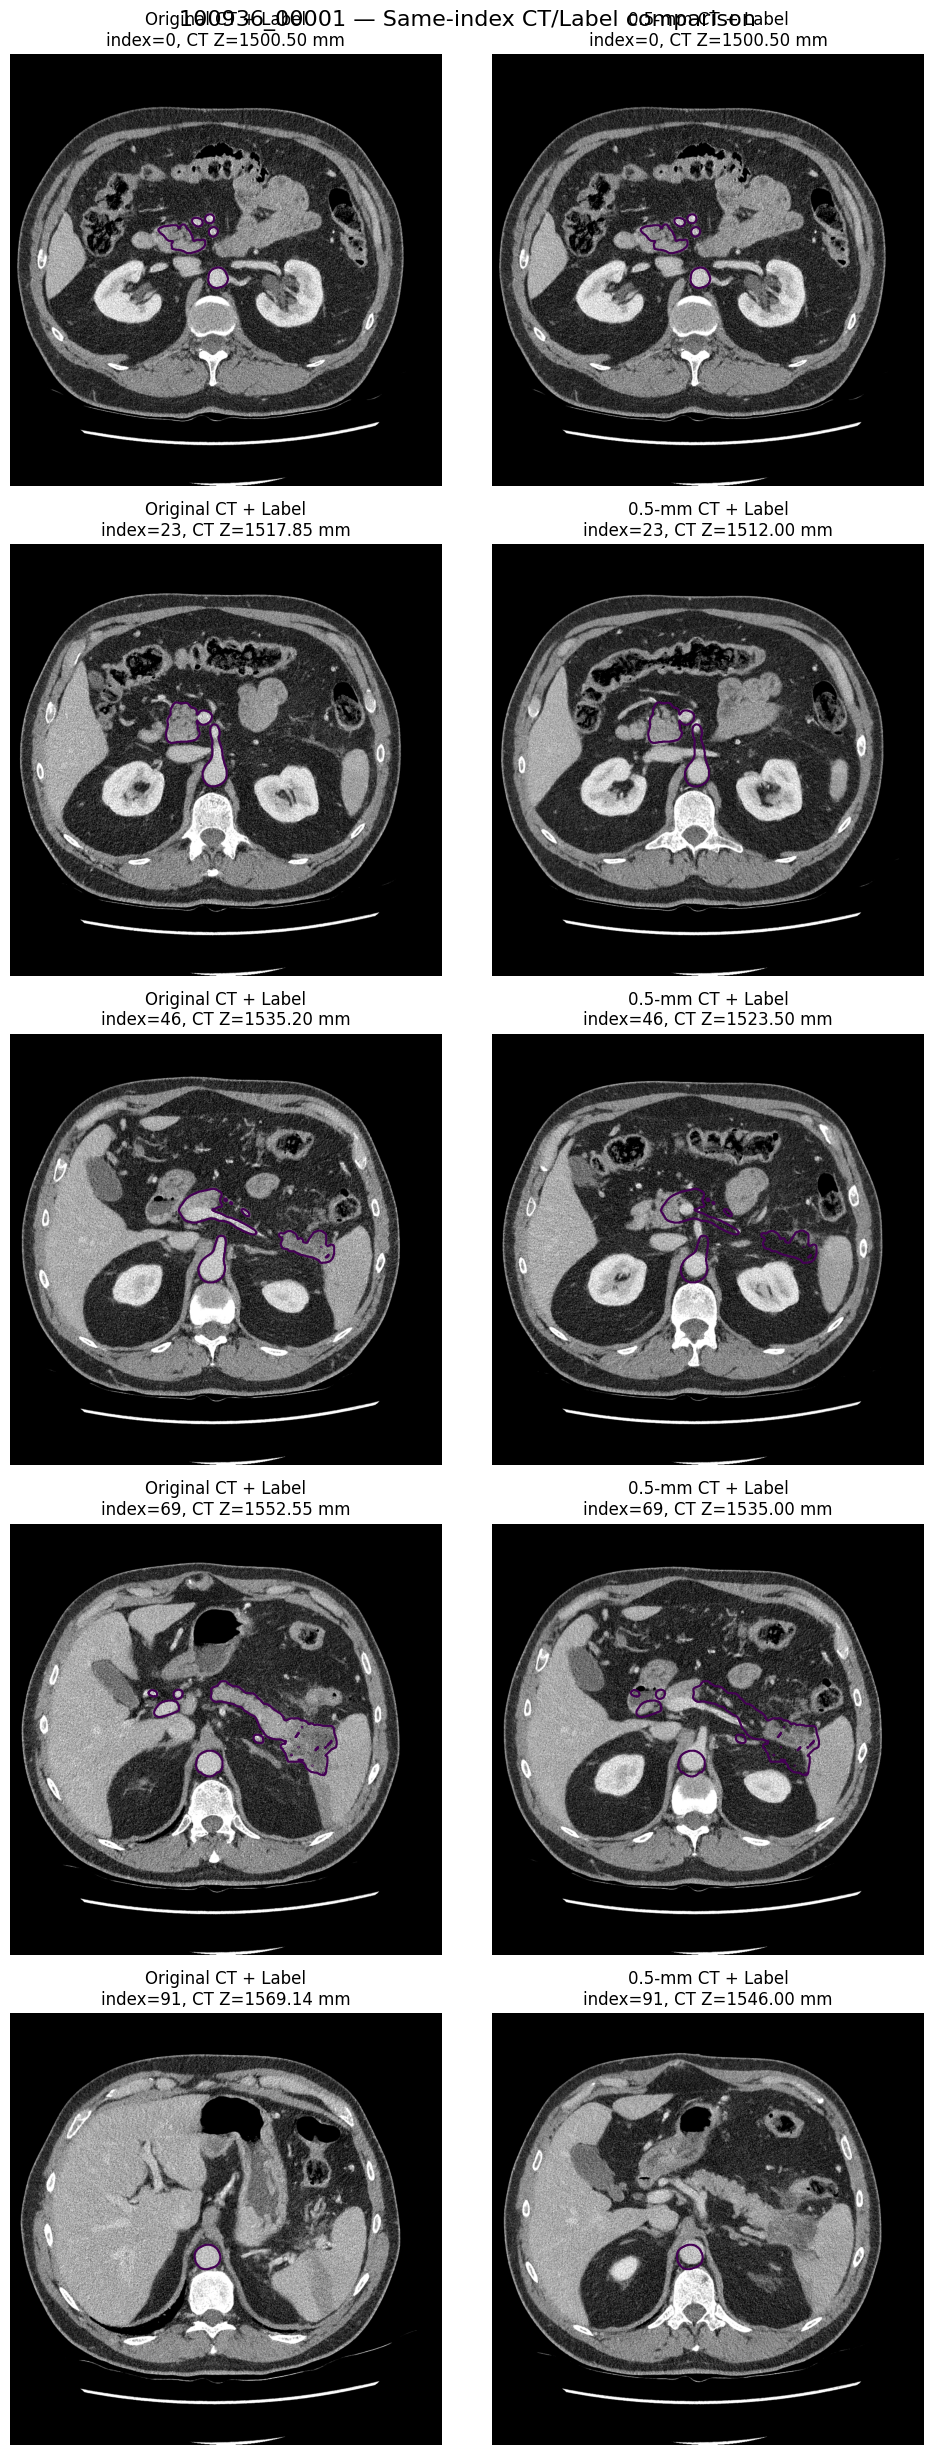

In [4]:
# ============================================================
# 100936_00001 — DECISIVE INDEX-BASED ALIGNMENT TEST
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
from pathlib import Path


study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ORIGINAL_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

RESAMPLED_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
    / f"{study_id}_ct_resampled_0p5mm.nii.gz"
)


# ------------------------------------------------------------
# Load original CT and label
# ------------------------------------------------------------

original_ct = sitk.ReadImage(
    str(ORIGINAL_CT_PATH)
)

label_img = sitk.ReadImage(
    str(LABEL_PATH)
)

label_array = sitk.GetArrayFromImage(
    label_img
)


# ------------------------------------------------------------
# Reader for resampled CT
# ------------------------------------------------------------

reader = sitk.ImageFileReader()
reader.SetFileName(
    str(RESAMPLED_CT_PATH)
)

reader.ReadImageInformation()


# ------------------------------------------------------------
# Read one axial slice from resampled CT
# ------------------------------------------------------------

def read_resampled_slice(z):

    size = list(reader.GetSize())

    index = [0, 0, int(z)]

    size[2] = 1

    reader.SetExtractIndex(index)
    reader.SetExtractSize(size)

    img = reader.Execute()

    return sitk.GetArrayFromImage(img)[0]


# ------------------------------------------------------------
# Read one slice from original CT
# ------------------------------------------------------------

def read_original_slice(z):

    extracted = sitk.Extract(
        original_ct,
        [
            original_ct.GetSize()[0],
            original_ct.GetSize()[1],
            1
        ],
        [0, 0, int(z)]
    )

    return sitk.GetArrayFromImage(extracted)[0]


# ------------------------------------------------------------
# Window
# ------------------------------------------------------------

window_center = 40
window_width = 400

window_min = window_center - window_width / 2
window_max = window_center + window_width / 2


def window_slice(arr):

    arr = arr.astype(
        np.float32,
        copy=False
    )

    return np.clip(
        (arr - window_min)
        / (window_max - window_min),
        0,
        1
    )


# ------------------------------------------------------------
# Test slices
# ------------------------------------------------------------

test_slices = [0, 23, 46, 69, 91]


fig, axes = plt.subplots(
    len(test_slices),
    2,
    figsize=(10, 5 * len(test_slices))
)


for row, z in enumerate(test_slices):

    label_slice = label_array[z]

    # ========================================================
    # LEFT — ORIGINAL CT + LABEL
    # ========================================================

    original_slice = read_original_slice(z)

    axes[row, 0].imshow(
        window_slice(original_slice),
        cmap="gray"
    )

    mask = label_slice > 0

    if np.any(mask):

        axes[row, 0].contour(
            mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.5
        )

    original_physical_z = (
        original_ct.GetOrigin()[2]
        + z * original_ct.GetSpacing()[2]
    )

    axes[row, 0].set_title(
        f"Original CT + Label\n"
        f"index={z}, CT Z={original_physical_z:.2f} mm"
    )

    axes[row, 0].axis("off")


    # ========================================================
    # RIGHT — RESAMPLED CT + SAME LABEL INDEX
    # ========================================================

    resampled_slice = read_resampled_slice(z)

    axes[row, 1].imshow(
        window_slice(resampled_slice),
        cmap="gray"
    )

    if np.any(mask):

        axes[row, 1].contour(
            mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.5
        )

    resampled_physical_z = (
        reader.GetOrigin()[2]
        + z * reader.GetSpacing()[2]
    )

    axes[row, 1].set_title(
        f"0.5-mm CT + Label\n"
        f"index={z}, CT Z={resampled_physical_z:.2f} mm"
    )

    axes[row, 1].axis("off")


plt.suptitle(
    "100936_00001 — Same-index CT/Label comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

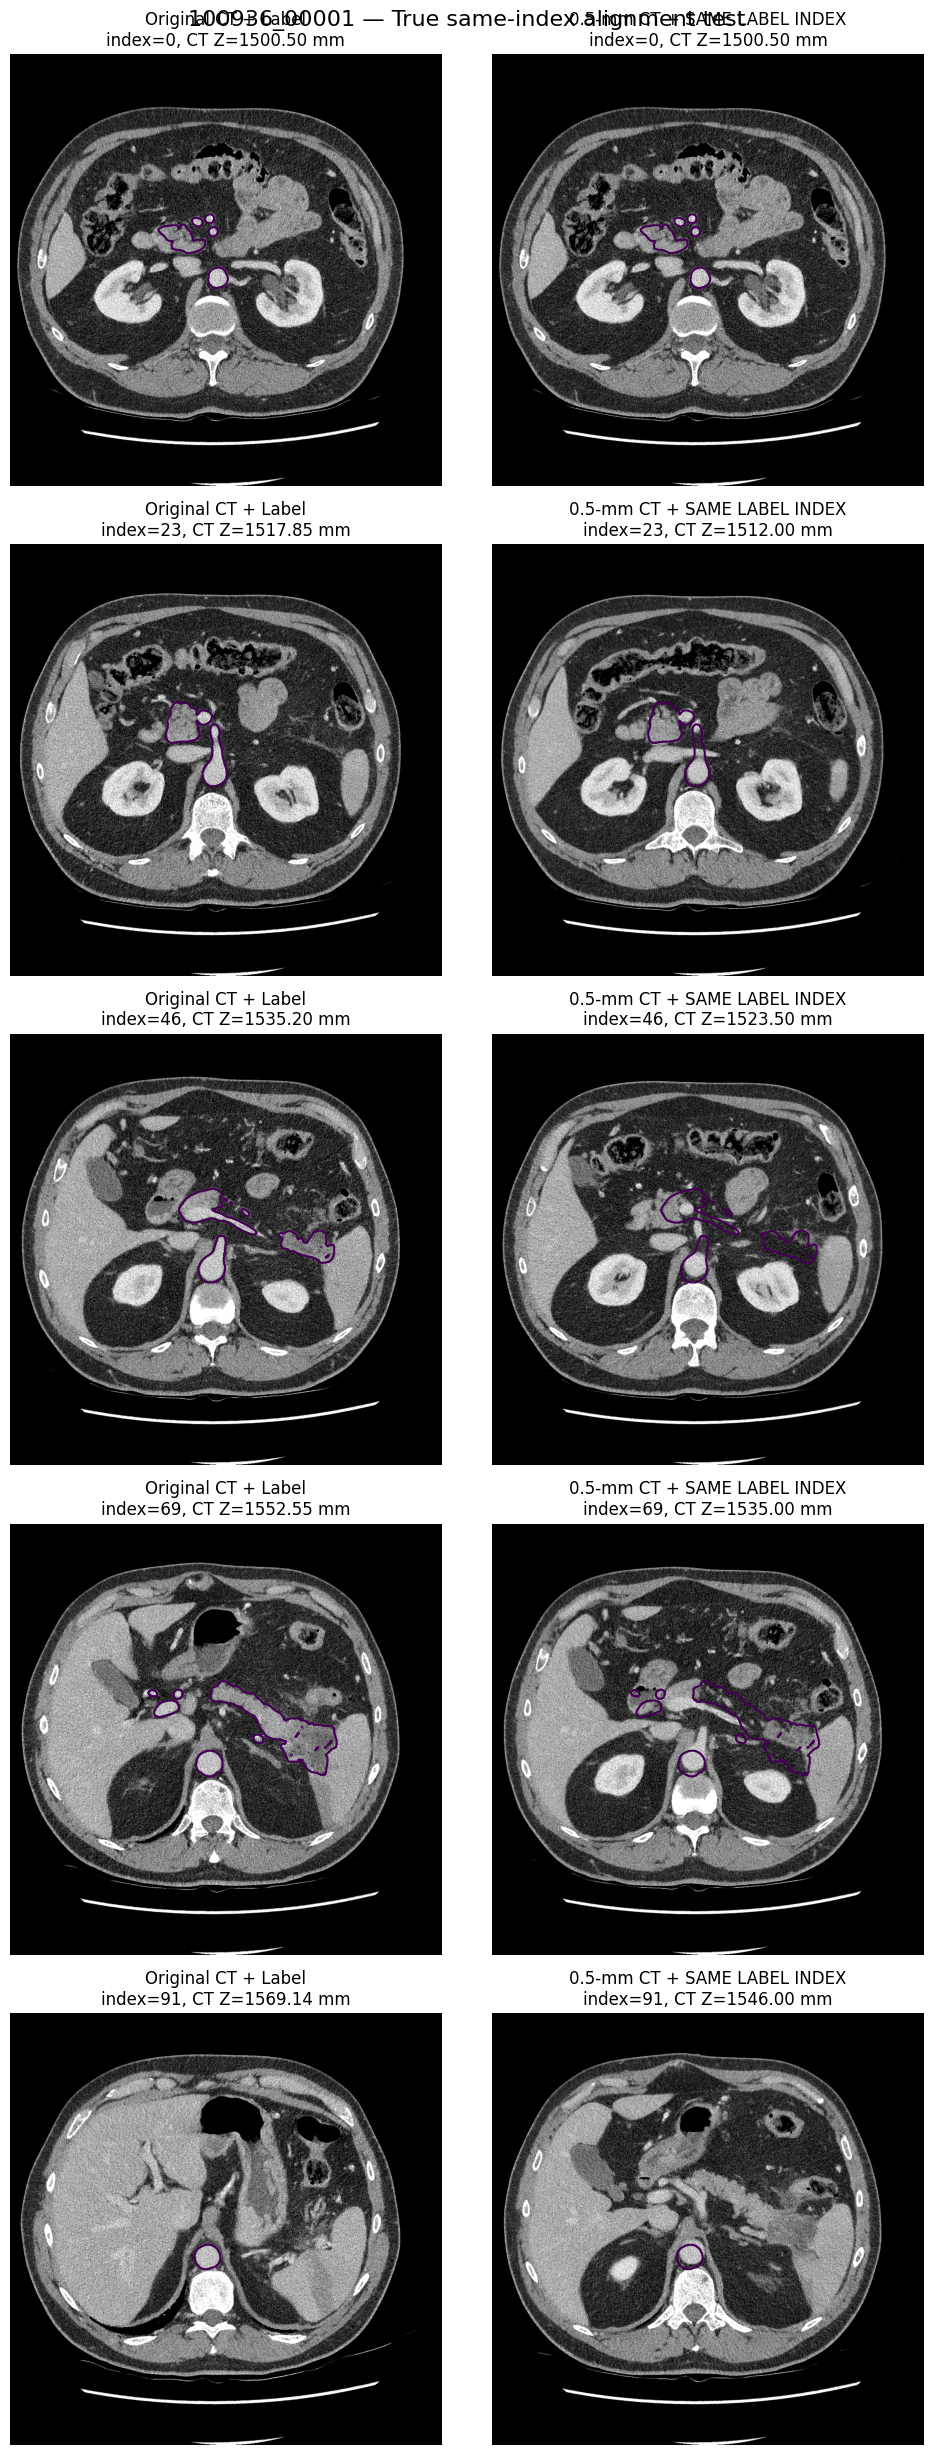

In [5]:
# ============================================================
# 100936_00001 — TRUE SAME-INDEX COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
from pathlib import Path


study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

ORIGINAL_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

RESAMPLED_CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
    / f"{study_id}_ct_resampled_0p5mm.nii.gz"
)


# ------------------------------------------------------------
# Load original CT + label
# ------------------------------------------------------------

original_ct = sitk.ReadImage(
    str(ORIGINAL_CT_PATH)
)

label_img = sitk.ReadImage(
    str(LABEL_PATH)
)

label_array = sitk.GetArrayFromImage(
    label_img
)


# ------------------------------------------------------------
# Reader for resampled CT
# ------------------------------------------------------------

reader = sitk.ImageFileReader()
reader.SetFileName(
    str(RESAMPLED_CT_PATH)
)

reader.ReadImageInformation()


def read_original_slice(z):

    extracted = sitk.Extract(
        original_ct,
        [
            original_ct.GetSize()[0],
            original_ct.GetSize()[1],
            1
        ],
        [0, 0, int(z)]
    )

    return sitk.GetArrayFromImage(extracted)[0]


def read_resampled_slice(z):

    size = list(reader.GetSize())
    index = [0, 0, int(z)]

    size[2] = 1

    reader.SetExtractIndex(index)
    reader.SetExtractSize(size)

    img = reader.Execute()

    return sitk.GetArrayFromImage(img)[0]


# ------------------------------------------------------------
# Display window
# ------------------------------------------------------------

window_center = 40
window_width = 400

window_min = window_center - window_width / 2
window_max = window_center + window_width / 2


def window_slice(arr):

    arr = arr.astype(
        np.float32,
        copy=False
    )

    return np.clip(
        (arr - window_min)
        / (window_max - window_min),
        0,
        1
    )


# ------------------------------------------------------------
# Test slices
# ------------------------------------------------------------

test_slices = [0, 23, 46, 69, 91]


fig, axes = plt.subplots(
    len(test_slices),
    2,
    figsize=(10, 5 * len(test_slices))
)


for row, z in enumerate(test_slices):

    mask = label_array[z] > 0

    # ========================================================
    # LEFT: ORIGINAL CT + LABEL
    # ========================================================

    original_slice = read_original_slice(z)

    original_z = (
        original_ct.GetOrigin()[2]
        + z * original_ct.GetSpacing()[2]
    )

    axes[row, 0].imshow(
        window_slice(original_slice),
        cmap="gray"
    )

    if np.any(mask):

        axes[row, 0].contour(
            mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.5
        )

    axes[row, 0].set_title(
        f"Original CT + Label\n"
        f"index={z}, CT Z={original_z:.2f} mm"
    )

    axes[row, 0].axis("off")


    # ========================================================
    # RIGHT: RESAMPLED CT + SAME INDEX
    # ========================================================

    resampled_slice = read_resampled_slice(z)

    resampled_z = (
        reader.GetOrigin()[2]
        + z * reader.GetSpacing()[2]
    )

    axes[row, 1].imshow(
        window_slice(resampled_slice),
        cmap="gray"
    )

    if np.any(mask):

        axes[row, 1].contour(
            mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.5
        )

    axes[row, 1].set_title(
        f"0.5-mm CT + SAME LABEL INDEX\n"
        f"index={z}, CT Z={resampled_z:.2f} mm"
    )

    axes[row, 1].axis("off")


plt.suptitle(
    "100936_00001 — True same-index alignment test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CREATE REPAIRED 100936_00001 MANUAL LABEL
# ============================================================
#
# IMPORTANT:
# - Original label is NOT modified.
# - Voxel label values are preserved exactly.
# - Output is stored as uint8 because labels are integer-valued.
# - Spatial geometry is copied from the original CT.
# ============================================================

from pathlib import Path
import numpy as np
import nibabel as nib


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

study_id = "100936_00001"

PROJECT_ROOT = Path.cwd().parent

CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / f"{study_id}_0000.nii.gz"
)

ORIGINAL_LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / f"{study_id}.nii.gz"
)

INVESTIGATION_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
)

INVESTIGATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPAIRED_PATH = (
    INVESTIGATION_DIR
    / f"{study_id}_repaired.nii.gz"
)

TEMP_MEMMAP_PATH = (
    INVESTIGATION_DIR
    / f"{study_id}_repaired_uint8.dat"
)


print("=" * 70)
print("CREATING REPAIRED MANUAL LABEL")
print("=" * 70)

print("\nOriginal CT:")
print(CT_PATH)

print("\nOriginal manual label:")
print(ORIGINAL_LABEL_PATH)

print("\nRepaired label:")
print(REPAIRED_PATH)


# ------------------------------------------------------------
# Existence checks
# ------------------------------------------------------------

if not CT_PATH.exists():
    raise FileNotFoundError(
        f"Original CT not found:\n{CT_PATH}"
    )

if not ORIGINAL_LABEL_PATH.exists():
    raise FileNotFoundError(
        f"Original manual label not found:\n"
        f"{ORIGINAL_LABEL_PATH}"
    )


# ------------------------------------------------------------
# Load headers/proxies
#
# nibabel does NOT load the complete voxel arrays here.
# ------------------------------------------------------------

ct_img = nib.load(str(CT_PATH))

label_img = nib.load(
    str(ORIGINAL_LABEL_PATH)
)

ct_proxy = ct_img.dataobj
label_proxy = label_img.dataobj


# ------------------------------------------------------------
# Basic geometry
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL GEOMETRY")
print("-" * 70)

print(
    "CT shape      :",
    ct_img.shape
)

print(
    "Label shape   :",
    label_img.shape
)

print(
    "CT zooms      :",
    ct_img.header.get_zooms()[:3]
)

print(
    "Label zooms   :",
    label_img.header.get_zooms()[:3]
)

print(
    "CT affine:\n",
    ct_img.affine
)

print(
    "\nLabel affine:\n",
    label_img.affine
)


# ------------------------------------------------------------
# Confirm dimensions
# ------------------------------------------------------------

if ct_img.shape[:3] != label_img.shape[:3]:
    raise ValueError(
        "CT and label dimensions do not match:\n"
        f"CT: {ct_img.shape}\n"
        f"Label: {label_img.shape}"
    )


# ------------------------------------------------------------
# Create uint8 temporary array on disk
#
# NIfTI shape is X, Y, Z.
# We process one Z slice at a time.
# ------------------------------------------------------------

shape = label_img.shape[:3]

print("\n" + "-" * 70)
print("CREATING UINT8 WORKING ARRAY")
print("-" * 70)

print("Shape:", shape)
print("Slices:", shape[2])

mask_memmap = np.memmap(
    TEMP_MEMMAP_PATH,
    dtype=np.uint8,
    mode="w+",
    shape=shape,
)


# ------------------------------------------------------------
# Preserve label voxel values and verify them
# ------------------------------------------------------------

original_counts = {}

print("\nProcessing slices...")

for z in range(shape[2]):

    # Read only one slice from the original label
    slice_data = np.asarray(
        label_proxy[:, :, z]
    )

    # Labels should be integer-valued
    if not np.all(
        np.isfinite(slice_data)
    ):
        raise ValueError(
            f"Non-finite values found in label slice {z}."
        )

    rounded = np.rint(slice_data)

    if not np.array_equal(
        slice_data,
        rounded
    ):
        raise ValueError(
            f"Non-integer label values found in slice {z}."
        )

    # Ensure uint8 is safe
    if (
        rounded.min() < 0
        or rounded.max() > 255
    ):
        raise ValueError(
            f"Label values outside uint8 range "
            f"found in slice {z}."
        )

    uint8_slice = rounded.astype(
        np.uint8
    )

    mask_memmap[:, :, z] = uint8_slice

    # Count values for verification
    values, counts = np.unique(
        uint8_slice,
        return_counts=True,
    )

    for value, count in zip(
        values,
        counts,
    ):
        original_counts[int(value)] = (
            original_counts.get(
                int(value),
                0,
            )
            + int(count)
        )

    if (
        (z + 1) % 25 == 0
        or z == shape[2] - 1
    ):
        print(
            f"Processed slices: "
            f"{z + 1}/{shape[2]}"
        )


# Ensure data is written to disk
mask_memmap.flush()


# ------------------------------------------------------------
# Create repaired NIfTI
#
# The CT affine is intentionally used as the repaired label
# geometry because our investigation showed index-wise
# anatomical correspondence between the original CT and label.
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CREATING REPAIRED NIFTI")
print("-" * 70)

repaired_header = label_img.header.copy()

repaired_header.set_data_dtype(
    np.uint8
)

repaired_header.set_slope_inter(
    1.0,
    0.0,
)

repaired_header.set_qform(
    ct_img.affine,
    code=1,
)

repaired_header.set_sform(
    ct_img.affine,
    code=1,
)

repaired_img = nib.Nifti1Image(
    mask_memmap,
    ct_img.affine,
    header=repaired_header,
)

repaired_img.set_qform(
    ct_img.affine,
    code=1,
)

repaired_img.set_sform(
    ct_img.affine,
    code=1,
)

nib.save(
    repaired_img,
    str(REPAIRED_PATH),
)


# ------------------------------------------------------------
# Remove temporary memmap
# ------------------------------------------------------------

del mask_memmap

try:
    TEMP_MEMMAP_PATH.unlink()
except FileNotFoundError:
    pass


print("\n✓ Repaired label created:")
print(REPAIRED_PATH)


# ============================================================
# VERIFY REPAIRED LABEL
# ============================================================

print("\n" + "=" * 70)
print("VERIFYING REPAIRED LABEL")
print("=" * 70)

repaired_check = nib.load(
    str(REPAIRED_PATH)
)

print("\nExists:")
print(REPAIRED_PATH.exists())

print("\nShape:")
print(
    repaired_check.shape
)

print("\nDtype:")
print(
    repaired_check.get_data_dtype()
)

print("\nSpacing:")
print(
    repaired_check.header.get_zooms()[:3]
)

print("\nCT spacing:")
print(
    ct_img.header.get_zooms()[:3]
)

print("\nRepaired affine:")
print(
    repaired_check.affine
)


# ------------------------------------------------------------
# Recalculate repaired label counts
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("LABEL VALUE VERIFICATION")
print("-" * 70)

repaired_proxy = repaired_check.dataobj

repaired_counts = {}

for z in range(shape[2]):

    slice_data = np.asarray(
        repaired_proxy[:, :, z]
    )

    values, counts = np.unique(
        slice_data,
        return_counts=True,
    )

    for value, count in zip(
        values,
        counts,
    ):
        repaired_counts[int(value)] = (
            repaired_counts.get(
                int(value),
                0,
            )
            + int(count)
        )


print("\nOriginal label counts:")
for value in sorted(original_counts):
    print(
        f"  {value}: "
        f"{original_counts[value]:,}"
    )

print("\nRepaired label counts:")
for value in sorted(repaired_counts):
    print(
        f"  {value}: "
        f"{repaired_counts[value]:,}"
    )


# ------------------------------------------------------------
# Exact count comparison
# ------------------------------------------------------------

if original_counts != repaired_counts:

    raise RuntimeError(
        "Label voxel counts changed during repair!"
    )

print(
    "\n✓ Label voxel counts are identical."
)


# ------------------------------------------------------------
# Geometry comparison
# ------------------------------------------------------------

ct_spacing = np.asarray(
    ct_img.header.get_zooms()[:3],
    dtype=float,
)

repaired_spacing = np.asarray(
    repaired_check.header.get_zooms()[:3],
    dtype=float,
)

if not np.allclose(
    ct_spacing,
    repaired_spacing,
    atol=1e-6,
):
    raise RuntimeError(
        "Repaired label spacing does not match CT."
    )

if not np.allclose(
    ct_img.affine,
    repaired_check.affine,
    atol=1e-5,
):
    raise RuntimeError(
        "Repaired label affine does not match CT."
    )


print(
    "✓ Repaired label geometry matches CT."
)


print("\n" + "=" * 70)
print("REPAIR COMPLETE")
print("=" * 70)

print(
    "\nOriginal label was NOT modified."
)

print(
    "Repaired file:"
)

print(
    REPAIRED_PATH
)

CREATING REPAIRED MANUAL LABEL

Original CT:
d:\Pancreatic_Cancer_Thesis\data\raw_ct\100936_00001_0000.nii.gz

Original manual label:
d:\Pancreatic_Cancer_Thesis\data\labels\Manual_Labels\100936_00001.nii.gz

Repaired label:
d:\Pancreatic_Cancer_Thesis\data\processed\anomaly_investigation\100936_00001_repaired.nii.gz

----------------------------------------------------------------------
ORIGINAL GEOMETRY
----------------------------------------------------------------------
CT shape      : (1024, 1024, 406)
Label shape   : (1024, 1024, 406)
CT zooms      : (np.float32(0.391006), np.float32(0.391006), np.float32(0.754321))
Label zooms   : (np.float32(0.391006), np.float32(0.391006), np.float32(0.5))
CT affine:
 [[-3.91005993e-01  0.00000000e+00  0.00000000e+00  1.86327942e+02]
 [ 0.00000000e+00 -3.91005993e-01  0.00000000e+00  1.99999817e+02]
 [ 0.00000000e+00  0.00000000e+00  7.54320979e-01  1.50050000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Label aff

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'd:\\Pancreatic_Cancer_Thesis\\data\\processed\\anomaly_investigation\\100936_00001_repaired_uint8.dat'

In [1]:
from pathlib import Path

REPAIRED_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "anomaly_investigation"
    / "100936_00001_repaired.nii.gz"
)

TEMP_MEMMAP_PATH = (
    Path.cwd().parent
    / "data"
    / "processed"
    / "anomaly_investigation"
    / "100936_00001_repaired_uint8.dat"
)

print("Repaired NIfTI exists:", REPAIRED_PATH.exists())

if REPAIRED_PATH.exists():
    print(
        "Size:",
        REPAIRED_PATH.stat().st_size / (1024**2),
        "MB"
    )

print("Temporary memmap exists:", TEMP_MEMMAP_PATH.exists())

Repaired NIfTI exists: True
Size: 1.9461565017700195 MB
Temporary memmap exists: True


In [2]:
import nibabel as nib
import numpy as np

ct_img = nib.load(
    str(
        Path.cwd().parent
        / "data"
        / "raw_ct"
        / "100936_00001_0000.nii.gz"
    )
)

repaired_img = nib.load(
    str(REPAIRED_PATH)
)

print("=" * 70)
print("REPAIRED LABEL CHECK")
print("=" * 70)

print("Shape:")
print(repaired_img.shape)

print("\nDtype:")
print(repaired_img.get_data_dtype())

print("\nCT spacing:")
print(ct_img.header.get_zooms()[:3])

print("Repaired spacing:")
print(repaired_img.header.get_zooms()[:3])

print("\nAffine matches CT:",
      np.allclose(
          repaired_img.affine,
          ct_img.affine,
          atol=1e-5
      ))

print("\nUnique labels:")

# Load only the repaired mask now; uint8 is much smaller.
repaired_data = np.asanyarray(
    repaired_img.dataobj
)

print(np.unique(repaired_data))

REPAIRED LABEL CHECK
Shape:
(1024, 1024, 406)

Dtype:
uint8

CT spacing:
(np.float32(0.391006), np.float32(0.391006), np.float32(0.754321))
Repaired spacing:
(np.float32(0.391006), np.float32(0.391006), np.float32(0.754321))

Affine matches CT: True

Unique labels:
[0 1 2 3 4 5 6]


In [3]:
# ============================================================
# VERIFY ORIGINAL VS REPAIRED LABEL VOXEL COUNTS
# ============================================================

import nibabel as nib
import numpy as np

PROJECT_ROOT = Path.cwd().parent

ORIGINAL_LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / "100936_00001.nii.gz"
)

REPAIRED_LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
    / "100936_00001_repaired.nii.gz"
)

original_img = nib.load(
    str(ORIGINAL_LABEL_PATH)
)

repaired_img = nib.load(
    str(REPAIRED_LABEL_PATH)
)

print("=" * 70)
print("ORIGINAL VS REPAIRED LABEL VERIFICATION")
print("=" * 70)

original = np.asanyarray(
    original_img.dataobj
)

repaired = np.asanyarray(
    repaired_img.dataobj
)

print("\nShapes:")
print("Original :", original.shape)
print("Repaired :", repaired.shape)

print("\nDtypes:")
print("Original :", original.dtype)
print("Repaired :", repaired.dtype)

if original.shape != repaired.shape:
    raise RuntimeError(
        "Original and repaired label shapes differ."
    )

# ------------------------------------------------------------
# Compare exact voxel values
# ------------------------------------------------------------

if not np.array_equal(
    original.astype(np.uint8),
    repaired
):
    raise RuntimeError(
        "Voxel values changed during repair!"
    )

print(
    "\n✓ Every label voxel is identical."
)

# ------------------------------------------------------------
# Label counts
# ------------------------------------------------------------

original_values, original_counts = np.unique(
    original,
    return_counts=True,
)

repaired_values, repaired_counts = np.unique(
    repaired,
    return_counts=True,
)

print("\nLabel counts:")

for value in sorted(
    set(original_values.tolist())
    | set(repaired_values.tolist())
):

    original_count = int(
        original_counts[
            np.where(
                original_values == value
            )[0][0]
        ]
    ) if value in original_values else 0

    repaired_count = int(
        repaired_counts[
            np.where(
                repaired_values == value
            )[0][0]
        ]
    ) if value in repaired_values else 0

    status = (
        "✓"
        if original_count == repaired_count
        else "✗"
    )

    print(
        f"  Label {int(value)}: "
        f"{original_count:,} → "
        f"{repaired_count:,} {status}"
    )

# ------------------------------------------------------------
# Geometry
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("GEOMETRY")
print("-" * 70)

print(
    "Original spacing :",
    original_img.header.get_zooms()[:3]
)

print(
    "Repaired spacing :",
    repaired_img.header.get_zooms()[:3]
)

print(
    "\nOriginal affine == repaired affine:",
    np.allclose(
        original_img.affine,
        repaired_img.affine,
        atol=1e-6,
    )
)

print("\n" + "=" * 70)
print("✓ REPAIR VERIFICATION COMPLETE")
print("=" * 70)

ORIGINAL VS REPAIRED LABEL VERIFICATION

Shapes:
Original : (1024, 1024, 406)
Repaired : (1024, 1024, 406)

Dtypes:
Original : uint16
Repaired : uint8

✓ Every label voxel is identical.

Label counts:
  Label 0: 424,245,469 → 424,245,469 ✓
  Label 1: 401,394 → 401,394 ✓
  Label 2: 147,488 → 147,488 ✓
  Label 3: 386,339 → 386,339 ✓
  Label 4: 541,024 → 541,024 ✓
  Label 5: 136 → 136 ✓
  Label 6: 6 → 6 ✓

----------------------------------------------------------------------
GEOMETRY
----------------------------------------------------------------------
Original spacing : (np.float32(0.391006), np.float32(0.391006), np.float32(0.5))
Repaired spacing : (np.float32(0.391006), np.float32(0.391006), np.float32(0.754321))

Original affine == repaired affine: False

✓ REPAIR VERIFICATION COMPLETE


In [4]:
# ============================================================
# FINAL 100936 REPAIRED LABEL GEOMETRY VERIFICATION
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np

PROJECT_ROOT = Path.cwd().parent

CT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw_ct"
    / "100936_00001_0000.nii.gz"
)

ORIGINAL_LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "labels"
    / "Manual_Labels"
    / "100936_00001.nii.gz"
)

REPAIRED_LABEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "anomaly_investigation"
    / "100936_00001_repaired.nii.gz"
)

ct = nib.load(str(CT_PATH))
original = nib.load(str(ORIGINAL_LABEL_PATH))
repaired = nib.load(str(REPAIRED_LABEL_PATH))

print("=" * 70)
print("FINAL 100936_00001 REPAIR VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Shape
# ------------------------------------------------------------

print("\nShape")
print("CT       :", ct.shape)
print("Original :", original.shape)
print("Repaired :", repaired.shape)

assert ct.shape[:3] == repaired.shape[:3]

# ------------------------------------------------------------
# Dtype
# ------------------------------------------------------------

print("\nDtype")
print("Original :", original.get_data_dtype())
print("Repaired :", repaired.get_data_dtype())

# ------------------------------------------------------------
# Spacing
# ------------------------------------------------------------

ct_spacing = np.asarray(
    ct.header.get_zooms()[:3],
    dtype=float,
)

repaired_spacing = np.asarray(
    repaired.header.get_zooms()[:3],
    dtype=float,
)

print("\nSpacing")
print("CT       :", ct_spacing)
print("Original :", original.header.get_zooms()[:3])
print("Repaired :", repaired_spacing)

assert np.allclose(
    ct_spacing,
    repaired_spacing,
    atol=1e-6,
)

print("✓ Repaired spacing matches CT.")

# ------------------------------------------------------------
# Affine
# ------------------------------------------------------------

print("\nAffine")

print("CT affine:")
print(ct.affine)

print("\nRepaired label affine:")
print(repaired.affine)

affine_match = np.allclose(
    ct.affine,
    repaired.affine,
    atol=1e-5,
)

print(
    "\nCT affine == repaired affine:",
    affine_match,
)

assert affine_match

print("✓ Repaired affine matches CT.")

# ------------------------------------------------------------
# Origin / orientation
# ------------------------------------------------------------

print("\nOrigin")
print(
    "CT       :",
    ct.header.get_qform()[:3, 3]
)

print(
    "Repaired :",
    repaired.header.get_qform()[:3, 3]
)

# ------------------------------------------------------------
# Voxel-data preservation
# ------------------------------------------------------------

original_data = np.asarray(
    original.dataobj
)

repaired_data = np.asarray(
    repaired.dataobj
)

voxel_identical = np.array_equal(
    original_data.astype(np.uint8),
    repaired_data,
)

print(
    "\nVoxel values identical:",
    voxel_identical,
)

assert voxel_identical

print("✓ Every segmentation voxel is preserved.")

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

original_labels = np.unique(
    original_data
).astype(int)

repaired_labels = np.unique(
    repaired_data
).astype(int)

print("\nLabels")
print("Original :", original_labels)
print("Repaired :", repaired_labels)

assert np.array_equal(
    original_labels,
    repaired_labels,
)

print("✓ Label set preserved.")

print("\n" + "=" * 70)
print("✓ REPAIRED LABEL PASSES GEOMETRY + DATA VERIFICATION")
print("=" * 70)

FINAL 100936_00001 REPAIR VERIFICATION

Shape
CT       : (1024, 1024, 406)
Original : (1024, 1024, 406)
Repaired : (1024, 1024, 406)

Dtype
Original : uint16
Repaired : uint8

Spacing
CT       : [0.39100599 0.39100599 0.75432098]
Original : (np.float32(0.391006), np.float32(0.391006), np.float32(0.5))
Repaired : [0.39100599 0.39100599 0.75432098]
✓ Repaired spacing matches CT.

Affine
CT affine:
[[-3.91005993e-01  0.00000000e+00  0.00000000e+00  1.86327942e+02]
 [ 0.00000000e+00 -3.91005993e-01  0.00000000e+00  1.99999817e+02]
 [ 0.00000000e+00  0.00000000e+00  7.54320979e-01  1.50050000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Repaired label affine:
[[-3.91005993e-01  0.00000000e+00  0.00000000e+00  1.86327942e+02]
 [ 0.00000000e+00 -3.91005993e-01  0.00000000e+00  1.99999817e+02]
 [ 0.00000000e+00  0.00000000e+00  7.54320979e-01  1.50050000e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

CT affine == repaired affine: True
✓ R

PROCESSING REPAIRED CASE: 100936_00001

✓ Original CT exists
✓ Original PANORAMA label exists
✓ Repaired label exists

----------------------------------------------------------------------
STEP 1 — LOADING CASE
----------------------------------------------------------------------


NameError: name 'prep' is not defined